# Modelo 2 — Random Forest
**Dataset:** https://doi.org/10.5281/zenodo.4064801

### Pipeline
1. Diferenças no tratamento dos dados em relação a CNN 1D
2. Configurações básicas e Carregamento
3. Extração de Características (Feature Engineering)
4. Divisão e balanceamento
5. Treinamento com validação cruzada (5-fold)
6. Gráfico de aprendizado em relação ao treino
7. Avaliação no Conjunto teste
8. Comparação com CNN (Modelo 1)

---
## 1. Diferenças no tratamento dos dados em relação a CNN 1D
Random forest é um modelo de treinamento clássico de Machine Learning no qual trabalha com dados tabulares (linhas e colunas), isso significa que os modelos enxergam os dados de forma diferente, ele não consegue receber matrizes brutas e aprender os padrões temporais sozinho. 
Portanto, é necessário que o primeiro passo seja a Extração de Características (Feature Engineering) específicas necessárias para o prosseguimento da comparação, sendo realizada de forma manual. Diferenças em relação ao histórico gerado pela CNN são causadas pois o Random Forest não treina por "épocas" (epochs) nem calcula "loss" (perda) progressiva, em vez de mostrar a evolução por épocas, mostra-se exatamente quais animais caíram na validação daquele fold e qual foi o F1-Score no Treino vs. Validação.

---
## 2. Configurações básicas e Carregamento
### 2.1 Carregamento do animal

In [ ]:
import pandas as pd
import numpy as np
from pathlib import Path

PASTA_DATASET = Path('../dataset') # Ajuste se os seus CSVs estiverem em outra pasta
AMOSTRAS_POR_JANELA = 900
TODOS_IDS = [f'{i:02d}' for i in range(1, 19)]

# FUNÇÃO ORIGINAL DE CARREGAMENTO E FUSÃO (Alinha os timestamps)
def carregar_animal(animal_id: str) -> pd.DataFrame:
    path_accel  = PASTA_DATASET / f'accel-{animal_id}.csv'
    path_halter = PASTA_DATASET / f'halter-{animal_id}.csv'

    # Carrega os dados
    accel  = pd.read_csv(path_accel,  parse_dates=['timestamp'])
    halter = pd.read_csv(path_halter, parse_dates=['timestamp'])
    
    # Remove qualquer espaço invisível dos cabeçalhos dos dois arquivos
    accel.columns = accel.columns.str.strip()
    halter.columns = halter.columns.str.strip()

    # Arredonda para 100ms
    accel['timestamp']  = accel['timestamp'].dt.round('100ms')
    halter['timestamp'] = halter['timestamp'].dt.round('100ms')

    # Renomeia os eixos (caso ainda não estejam renomeados)
    if 'x' in accel.columns:
        accel  = accel.rename(columns={'x': 'acc_x', 'y': 'acc_y', 'z': 'acc_z'})
        
    # Renomeia a coluna do Halter (seja ela qual for, assumindo que é a segunda coluna)
    # Necessário pois o arquivo CSV estava dando erros de digitação
    # Como a primeira coluna é 'timestamp', a segunda será o nosso rótulo
    coluna_rotulo = halter.columns[1] 
    halter = halter.rename(columns={coluna_rotulo: 'rotulo'})

    df = pd.merge(accel, halter, on='timestamp', how='inner')
    df = df.sort_values('timestamp').reset_index(drop=True)
    df.insert(0, 'animal_id', animal_id)
    return df

---
## 3. Extração de Características
### 3.1 Diferença Discreta
$$\Delta s[t] = s[t] - s[t-1], \quad \forall s \in \{x, y, z\}$$

Elimina vieses estáticos de orientação do colar (Pavlovic et al., 2021 — Eq. 1).

### 3.2 Janelamento de 90 s
Cada janela de 900 amostras recebe um único rótulo por **votação majoritária**.

### 3.3 Atributos Estatísticos
Para cada eixo (x, y, z) são extraídas **5 características estatísticas** por janela:

- **Média** ($\mu$): Valor central das diferenças discretas
- **Desvio Padrão** ($\sigma$): Variabilidade das acelerações
- **Mínimo** (Min): Menor valor de aceleração
- **Máximo** (Max): Maior valor de aceleração
- **Amplitude** (Amp): $\text{Amp} = \text{Max} - \text{Min}$

**Total de features:** 15 (5 características × 3 eixos), mais `animal_id` e `rotulo`.

In [ ]:
import numpy as np
import pandas as pd


def diferenca_discreta(df: pd.DataFrame) -> pd.DataFrame:
    df_temp = df.copy()
    for col in ['acc_x', 'acc_y', 'acc_z']:
        df_temp[col] = df_temp[col].diff()
    return df_temp.dropna().reset_index(drop=True)

# Janelamento para o Random Forest
def janelamento_rf(df: pd.DataFrame, animal_id: str) -> list:
    janelas = []
    AMOSTRAS_POR_JANELA = 900
    n_janelas = len(df) // AMOSTRAS_POR_JANELA
    
    for i in range(n_janelas):
        bloco = df.iloc[i * AMOSTRAS_POR_JANELA : (i + 1) * AMOSTRAS_POR_JANELA]
        rotulo = int(bloco['rotulo'].mode()[0])  # votação majoritária - A label se chama classification no csv
        
        # Em vez de salvar o bloco bruto, calculamos as FEATURES (Características)
        x_diff = bloco['acc_x'].values
        y_diff = bloco['acc_y'].values
        z_diff = bloco['acc_z'].values
        
        # Montando o vetor de características desta janela
        features = {
            'animal_id': animal_id,
            'rotulo': rotulo,
            
            'x_media': np.mean(x_diff), 'x_std': np.std(x_diff), 'x_min': np.min(x_diff), 'x_max': np.max(x_diff), 'x_amp': np.max(x_diff) - np.min(x_diff),
            'y_media': np.mean(y_diff), 'y_std': np.std(y_diff), 'y_min': np.min(y_diff), 'y_max': np.max(y_diff), 'y_amp': np.max(y_diff) - np.min(y_diff),
            'z_media': np.mean(z_diff), 'z_std': np.std(z_diff), 'z_min': np.min(z_diff), 'z_max': np.max(z_diff), 'z_amp': np.max(z_diff) - np.min(z_diff)
        }
        janelas.append(features)
        
    return janelas

In [7]:
# PIPELINE PRINCIPAL
todas_as_janelas = []

print("A iniciar a extração de características para o Random Forest...")

for aid in TODOS_IDS:
    try:
        # Passo A: Carrega e funde os dados corretamente (usando a função original)
        df_bruto = carregar_animal(aid)
        
        # Passo B: Aplica a diferença discreta
        df_limpo = diferenca_discreta(df_bruto)
        
        # Passo C: Extrai as características e guarda
        features_deste_animal = janelamento_rf(df_limpo, aid)
        todas_as_janelas.extend(features_deste_animal)
        
    except FileNotFoundError:
        print(f"  [Aviso] Ficheiros do animal {aid} não encontrados. A saltar...")
        
# Transforma a lista numa Tabela final
df_features_rf = pd.DataFrame(todas_as_janelas)

print(f"\nExtração concluída com sucesso!")
print(f"A tabela 'X' final tem {df_features_rf.shape[0]} linhas e {df_features_rf.shape[1]} colunas prontas para o modelo.")

A iniciar a extração de características para o Random Forest...

Extração concluída com sucesso!
A tabela 'X' final tem 139246 linhas e 17 colunas prontas para o modelo.


---
## 4. Divisão e balanceamento

In [ ]:
import json
import numpy as np
import pandas as pd
from pathlib import Path
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.model_selection import GroupKFold

# Separar dados de Treino e Teste (Garantindo que são os mesmos animais do Baseline)
animais_teste = ['04', '10', '11']
df_teste = df_features_rf[df_features_rf['animal_id'].isin(animais_teste)]
df_treino_full = df_features_rf[~df_features_rf['animal_id'].isin(animais_teste)]

# Balanceamento (Undersampling) apenas no conjunto de Treino
# Descobrimos qual é o rótulo que tem menos dados e igualamos os outros a esse valor
tamanho_minimo = df_treino_full['rotulo'].value_counts().min()
df_treino_bal = df_treino_full.groupby('rotulo').sample(n=tamanho_minimo, random_state=42)

print(f"Distribuição após balanceamento no Treino:\n{df_treino_bal['rotulo'].value_counts()}\n")

# Separar em X (características) e y (rótulos)
colunas_features = [c for c in df_features_rf.columns if c not in ['animal_id', 'rotulo']]

X_treino = df_treino_bal[colunas_features].values
y_treino = df_treino_bal['rotulo'].values
grupos_treino = df_treino_bal['animal_id'].values

X_teste = df_teste[colunas_features].values
y_teste = df_teste['rotulo'].values


Distribuição após balanceamento no Treino:
rotulo
0    21832
1    21832
2    21832
Name: count, dtype: int64



---
## 5. Treino com validação cruzada
- Cada fold: ~3 animais na validação, 12 no treino
- Cada animal aparece exatamente 1 vez na validação
- Modelo instanciado com 100 estimadores (`n_estimators=100`) e profundidade livre, treinamento concluído em etapa única (sem early stopping)

In [ ]:
PASTA_METRICS = Path('../results/metrics')
PASTA_METRICS.mkdir(parents=True, exist_ok=True) # Cria a pasta se ela não existir

gkf = GroupKFold(n_splits=5)
rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)

f1_folds = []
historico_rf = [] # Lista para guardar os dados do CSV

for fold, (idx_treino, idx_val) in enumerate(gkf.split(X_treino, y_treino, grupos_treino)):
    X_t, y_t = X_treino[idx_treino], y_treino[idx_treino]
    X_v, y_v = X_treino[idx_val], y_treino[idx_val]
    
    # Descobrir quais animais estão no conjunto de validação deste fold
    animais_val = np.unique(grupos_treino[idx_val])
    
    print(f"── Fold {fold+1}/5  |  validação: {list(animais_val)} ──")
    
    # Treinar o modelo
    rf.fit(X_t, y_t)
    
    # Fazer previsões no treino e na validação
    preds_t = rf.predict(X_t)
    preds_v = rf.predict(X_v)
    
    # Calcular métricas
    f1_t = f1_score(y_t, preds_t, average='macro')
    f1_v = f1_score(y_v, preds_v, average='macro')
    f1_folds.append(f1_v)
    
    # Print no estilo do Baseline (sem épocas, mostrando Treino vs Validação)
    print(f"  Treino concluído | f1_tr: {f1_t:.4f} | f1_val: {f1_v:.4f}")
    print(f"  → F1 (melhor modelo) fold {fold+1}: {f1_v:.4f}\n")
    
    # Salvar no histórico
    historico_rf.append({
        'fold': fold + 1,
        'animais_val': str(list(animais_val)),
        'f1_tr': f1_t,
        'f1_val': f1_v
    })

# Calcular a Média e Desvio Padrão dos folds
media_f1 = np.mean(f1_folds)
std_f1 = np.std(f1_folds)

print(f"  Média : {media_f1:.4f} ± {std_f1:.4f}\n")

# Salvar o histórico num ficheiro CSV
df_historico = pd.DataFrame(historico_rf)
caminho_csv = PASTA_METRICS / 'historico_rf.csv'
df_historico.to_csv(caminho_csv, index=False)
print(f"Histórico salvo em: {caminho_csv}")

# Treinar o modelo final com TODOS os dados de treino balanceados
print("\nA treinar o modelo final...")
rf.fit(X_treino, y_treino)

# Avaliar no conjunto de Teste (Animais 04, 10, 11)
print("\nA avaliar no conjunto de Teste...")
preds_teste = rf.predict(X_teste)

acc = accuracy_score(y_teste, preds_teste)
prec = precision_score(y_teste, preds_teste, average='macro', zero_division=0)
rec = recall_score(y_teste, preds_teste, average='macro', zero_division=0)
f1_teste = f1_score(y_teste, preds_teste, average='macro', zero_division=0)

print(f"Resultados Finais - Acurácia: {acc:.4f} | Precisão: {prec:.4f} | Recall: {rec:.4f} | F1-Macro: {f1_teste:.4f}")

# Guardar os resultados para comparar posteriormente
resultados_rf = {
    'modelo'   : 'Random Forest',
    'accuracy' : round(acc, 4),
    'precision': round(prec, 4),
    'recall'   : round(rec, 4),
    'f1_macro' : round(f1_teste, 4),
    'f1_folds' : f1_folds,
    'preds'    : preds_teste.tolist(),
    'labels'   : y_teste.tolist()
}

with open('../results/metrics/resultados_rf.json', 'w') as f:
    json.dump(resultados_rf, f, indent=2)

print("\nResultados guardados com sucesso em 'resultados_rf.json'!")

── Fold 1/5  |  validação: ['06', '12'] ──
  Treino concluído | f1_tr: 1.0000 | f1_val: 0.7809
  → F1 (melhor modelo) fold 1: 0.7809

── Fold 2/5  |  validação: ['01', '18'] ──
  Treino concluído | f1_tr: 1.0000 | f1_val: 0.8050
  → F1 (melhor modelo) fold 2: 0.8050

── Fold 3/5  |  validação: ['02', '03', '17'] ──
  Treino concluído | f1_tr: 1.0000 | f1_val: 0.7914
  → F1 (melhor modelo) fold 3: 0.7914

── Fold 4/5  |  validação: ['07', '14', '15', '16'] ──
  Treino concluído | f1_tr: 1.0000 | f1_val: 0.7513
  → F1 (melhor modelo) fold 4: 0.7513

── Fold 5/5  |  validação: ['05', '08', '09', '13'] ──
  Treino concluído | f1_tr: 1.0000 | f1_val: 0.7542
  → F1 (melhor modelo) fold 5: 0.7542

  Média : 0.7766 ± 0.0209

Histórico salvo em: ../results/metrics/historico_rf.csv

A treinar o modelo final...

A avaliar no conjunto de Teste...
Resultados Finais - Acurácia: 0.7636 | Precisão: 0.7443 | Recall: 0.7827 | F1-Macro: 0.7312

Resultados guardados com sucesso em 'resultados_rf.json'!


---
## 6. Gráfico de aprendizado em relação ao treino

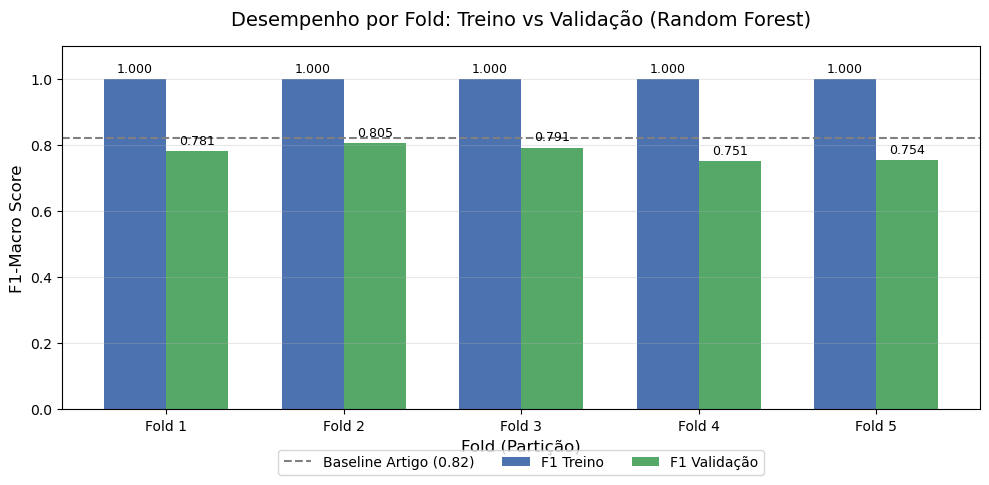

Gráfico salvo com sucesso em: ../results/figures/desempenho_folds_rf.png


In [10]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path

# Ajuste os caminhos conforme o seu projeto
PASTA_METRICS = Path('../results/metrics')
PASTA_FIGURES = Path('../results/figures')
PASTA_FIGURES.mkdir(parents=True, exist_ok=True) # Garante que a pasta figures existe

try:
    # Carregar o histórico que salvamos no passo anterior
    df_hist_rf = pd.read_csv(PASTA_METRICS / 'historico_rf.csv')

    fig, ax = plt.subplots(figsize=(10, 5))
    
    # Configuração das barras
    x = np.arange(len(df_hist_rf['fold']))
    width = 0.35
    
    # Plota as barras de Treino e Validação
    rects1 = ax.bar(x - width/2, df_hist_rf['f1_tr'], width, label='F1 Treino', color='#4C72B0')
    rects2 = ax.bar(x + width/2, df_hist_rf['f1_val'], width, label='F1 Validação', color='#55A868')

    # Configuração visual do gráfico
    ax.set_title('Desempenho por Fold: Treino vs Validação (Random Forest)', fontsize=14, pad=15)
    ax.set_xlabel('Fold (Partição)', fontsize=12)
    ax.set_ylabel('F1-Macro Score', fontsize=12)
    ax.set_xticks(x)
    ax.set_xticklabels([f"Fold {f}" for f in df_hist_rf['fold']])
    ax.set_ylim(0, 1.1)
    
    # Linha do Baseline do Artigo (0.82)
    ax.axhline(0.82, color='gray', linestyle='--', label='Baseline Artigo (0.82)')
    
    ax.legend(loc='lower center', bbox_to_anchor=(0.5, -0.2), ncol=3)
    ax.grid(alpha=0.3, axis='y')

    # Adiciona os números em cima de cada barra
    ax.bar_label(rects1, padding=3, fmt='%.3f', fontsize=9)
    ax.bar_label(rects2, padding=3, fmt='%.3f', fontsize=9)

    plt.tight_layout()
    
    # Salvar a figura com alta qualidade
    caminho_fig = PASTA_FIGURES / 'desempenho_folds_rf.png'
    plt.savefig(caminho_fig, dpi=300, bbox_inches='tight')
    plt.show()
    
    print(f"Gráfico salvo com sucesso em: {caminho_fig}")

except FileNotFoundError:
    print("Erro: O arquivo 'historico_rf.csv' não foi encontrado. Certifique-se de ter rodado a célula de treinamento antes.")

---
## 7 Avaliação no conjunto teste
Usa o modelo do fold com maior F1 de validação.

In [11]:
import numpy as np
from sklearn.metrics import classification_report, accuracy_score, precision_score, recall_score, f1_score
from sklearn.ensemble import RandomForestClassifier

# 1. Encontrar o Melhor Fold dinamicamente
# np.argmax descobre o índice (0 a 4) do maior valor na lista f1_folds
indice_melhor_fold = int(np.argmax(f1_folds))
melhor_fold = indice_melhor_fold + 1

print(f'Preparando avaliação... Melhor fold identificado: {melhor_fold} (F1 val = {f1_folds[indice_melhor_fold]:.4f})')

# 2. Recuperar os índices de treino específicos desse fold campeão
for fold, (idx_treino, idx_val) in enumerate(gkf.split(X_treino, y_treino, grupos_treino)):
    if fold == indice_melhor_fold:
        # Isolamos os dados exatos que o modelo viu durante este fold
        X_t_melhor, y_t_melhor = X_treino[idx_treino], y_treino[idx_treino]
        break

# 3. Treinar o modelo rapidamente apenas com os dados do melhor fold
modelo_final = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
modelo_final.fit(X_t_melhor, y_t_melhor)

# 4. Fazer predições no conjunto de Teste (Animais 04, 10 e 11)
preds = modelo_final.predict(X_teste)
labels = y_teste

# 5. Calcular as métricas
acc  = accuracy_score(labels, preds)
prec = precision_score(labels, preds, average='macro', zero_division=0)
rec  = recall_score(labels, preds, average='macro', zero_division=0)
f1_teste = f1_score(labels, preds, average='macro', zero_division=0)

# 6. Imprimir o Relatório formatado
print('\n══ Métricas no Conjunto de Teste (Random Forest - Melhor Fold) ══')
print(f'  Accuracy  : {acc:.4f}')
print(f'  Precision : {prec:.4f}')
print(f'  Recall    : {rec:.4f}')
print(f'  F1 (macro): {f1_teste:.4f}')
print(f'  (Artigo   : Precision=0.84 | Recall=0.82 | F1=0.82)')
print()

# Dicionário de classes para o relatório final
CLASSES = {0: 'Outro', 1: 'Ruminação', 2: 'Comendo'}

print(
    classification_report(
        labels, preds,
        target_names=list(CLASSES.values()),
        zero_division=0
    )
)

Preparando avaliação... Melhor fold identificado: 2 (F1 val = 0.8050)

══ Métricas no Conjunto de Teste (Random Forest - Melhor Fold) ══
  Accuracy  : 0.7642
  Precision : 0.7435
  Recall    : 0.7826
  F1 (macro): 0.7318
  (Artigo   : Precision=0.84 | Recall=0.82 | F1=0.82)

              precision    recall  f1-score   support

       Outro       0.92      0.79      0.85      9246
   Ruminação       0.88      0.69      0.78      6870
     Comendo       0.42      0.87      0.57      2712

    accuracy                           0.76     18828
   macro avg       0.74      0.78      0.73     18828
weighted avg       0.84      0.76      0.78     18828



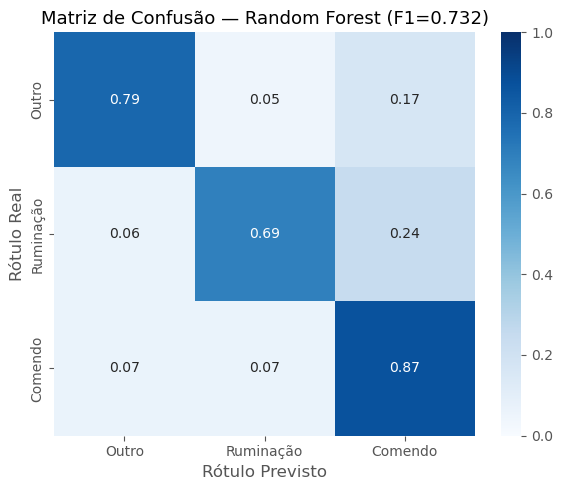

Matriz de Confusão salva com sucesso em: ../results/figures/matriz_confusao_rf.png


In [ ]:
import seaborn as sns
from sklearn.metrics import confusion_matrix

# 7. Gerar e plotar a Matriz de Confusão normalizada
cm = confusion_matrix(labels, preds)
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(
    cm_norm, annot=True, fmt='.2f', cmap='Blues',
    xticklabels=list(CLASSES.values()),
    yticklabels=list(CLASSES.values()),
    vmin=0, vmax=1, ax=ax
)
ax.set_xlabel('Rótulo Previsto', fontsize=12)
ax.set_ylabel('Rótulo Real',     fontsize=12)
ax.set_title(f'Matriz de Confusão — Random Forest (F1={f1_teste:.3f})', fontsize=13)
plt.tight_layout()
caminho_cm = PASTA_FIGURES / 'matriz_confusao_rf.png'
plt.savefig(caminho_cm, dpi=300)
plt.show()

print(f"Matriz de Confusão salva com sucesso em: {caminho_cm}")

---
## 8. Comparação com CNN (Modelo 1)

=== TABELA DE COMPARAÇÃO ===


,Modelo,Acurácia,Precisão,Recall,F1-Macro
0,CNN 1D,0.8273,0.7918,0.8222,0.7864
1,Random Forest,0.7636,0.7443,0.7827,0.7312


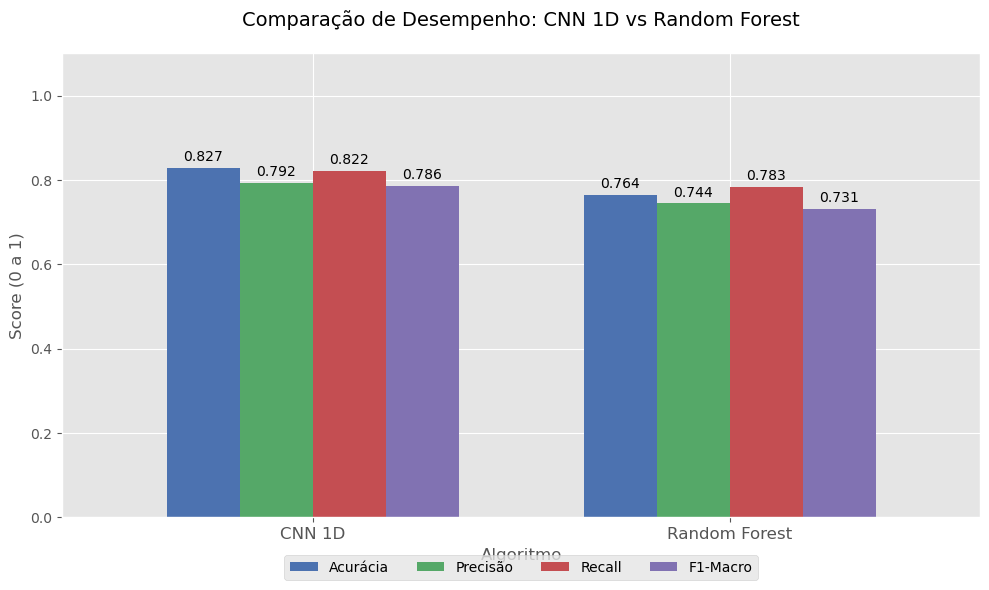

In [13]:
import json
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path

# Ajuste o caminho se os JSONs estiverem numa pasta específica
caminho_cnn = Path(PASTA_METRICS / 'resultados_cnn.json')
caminho_rf = Path(PASTA_METRICS / 'resultados_rf.json')

try:
    # 1. Carregar os ficheiros de resultados
    with open(caminho_cnn, 'r') as f:
        res_cnn = json.load(f)
        
    with open(caminho_rf, 'r') as f:
        res_rf = json.load(f)

    # 2. Criar uma Tabela Comparativa (DataFrame)
    metricas = {
        'Modelo': [res_cnn.get('modelo', 'CNN 1D'), res_rf.get('modelo', 'Random Forest')],
        'Acurácia': [res_cnn['accuracy'], res_rf['accuracy']],
        'Precisão': [res_cnn['precision'], res_rf['precision']],
        'Recall': [res_cnn['recall'], res_rf['recall']],
        'F1-Macro': [res_cnn['f1_macro'], res_rf['f1_macro']]
    }
    
    df_comparacao = pd.DataFrame(metricas)
    
    print("=== TABELA DE COMPARAÇÃO ===")
    display(df_comparacao) # Usa o display do Jupyter para uma tabela bonita

    # 3. Gerar o Gráfico de Barras
    plt.style.use('ggplot') # Estilo visual mais agradável
    ax = df_comparacao.set_index('Modelo').plot(
        kind='bar', 
        figsize=(10, 6), 
        color=['#4C72B0', '#55A868', '#C44E52', '#8172B2'],
        width=0.7
    )
    
    plt.title('Comparação de Desempenho: CNN 1D vs Random Forest', fontsize=14, pad=20)
    plt.ylabel('Score (0 a 1)', fontsize=12)
    plt.xlabel('Algoritmo', fontsize=12)
    plt.ylim(0, 1.1) # Vai até 1.1 para dar espaço à legenda
    plt.xticks(rotation=0, fontsize=12)
    plt.legend(loc='lower center', bbox_to_anchor=(0.5, -0.15), ncol=4)
    
    # Adicionar os valores numéricos em cima de cada barra
    for container in ax.containers:
        ax.bar_label(container, fmt='%.3f', padding=3, fontsize=10)
        
    plt.tight_layout()
    plt.show()

except FileNotFoundError as e:
    print(f"Erro: Não foi possível encontrar um dos ficheiros. Detalhe: {e}")
    print("Certifique-se de que 'resultados_cnn.json' e 'resultados_rf.json' estão na mesma pasta.")